# AS02 — Finetuning Gemma-3-270m-it on Colab (A100)

Runs the same LLMBox experiments as on the laptop (`as02/run_experiments.sh`), but on a GPU.
Runtime -> Change runtime type -> **A100** (or L4/T4; then use `DTYPE=float32` for T4).

**Before running**: in Colab *Secrets* (key icon on the left) add
* `HF_TOKEN` — Hugging Face read token (Gemma licence must be accepted on the HF page)
* `GH_TOKEN` — GitHub token with `repo` scope (the repo is private) — or upload the repo zip instead.


In [1]:
!nvidia-smi
import torch; print(torch.__version__, torch.cuda.is_available(), torch.cuda.get_device_name(0))

Fri Sep 25 16:38:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             47W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# 1. get the code (private repo) -------------------------------------------
from google.colab import userdata
import os
GH = userdata.get('GH_TOKEN')
!git clone https://{GH}@github.com/yarayaocmu/95864-AS02-finetune-llmbox.git llmbox
%cd llmbox
!git log --oneline | head -3

Cloning into 'llmbox'...
remote: Enumerating objects: 1061, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 1061 (delta 0), reused 1 (delta 0), pack-reused 1057 (from 1)
Receiving objects: 100% (1061/1061), 137.28 MiB | 31.11 MiB/s, done.
Resolving deltas: 100% (577/577), done.
/content/llmbox
f8bbdcf Colab: remove preinstalled torchao (incompatible with transformers 5)
652414c AS02: data pipeline, LLMBox patches, experiment/eval scripts, Colab notebook
d924984 Revise directory structure and add new file entries


In [3]:
# 2. dependencies (Colab already has torch) ---------------------------------
# Colab ships torchao 0.10, which transformers>=5 refuses to import next to; we do not need it.
!pip uninstall -y -q torchao
!pip install -q -r requirements_as02.txt
import transformers, peft; print('transformers', transformers.__version__, 'peft', peft.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.1 MB/s eta 0:00:00
transformers 5.16.1 peft 0.20.0


In [4]:
# 3. models --------------------------------------------------------------------
from huggingface_hub import login, snapshot_download
login(token=userdata.get('HF_TOKEN'))
snapshot_download('google/gemma-3-270m-it', local_dir='models/llms/google/gemma-3-270m-it')
# judge model for Part D (different model family from the one under test)
snapshot_download('microsoft/Phi-4-mini-instruct', local_dir='models/llms/microsoft/phi4-mini-instruct')
os.environ['AS02_JUDGE_MODEL'] = os.path.abspath('models/llms/microsoft/phi4-mini-instruct')
!ls models/llms/google/gemma-3-270m-it

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

added_tokens.json	model.safetensors	 tokenizer.json
chat_template.jinja	README.md		 tokenizer.model
config.json		special_tokens_map.json
generation_config.json	tokenizer_config.json


In [5]:
# 4. Part A: LLMBox prepare_data (re-split with the same seed) + tokenizer/batch analysis
!HF_HUB_OFFLINE=1 python3 -m startllm mode=prepare_data data=jsonl \
    data.path=data/as02/transformed/medrx_experience.jsonl data.output_dir=data/as02/splits \
    data.train_fraction=0.8 model=gemma3_270m model.source=local \
    model.local_path=models/llms/google/gemma-3-270m-it training.max_length=512 2>&1 | grep '\[info\]'
!python3 as02/part_a_restore_meta.py
!python3 as02/part_a_tokenize_batches.py --model models/llms/google/gemma-3-270m-it | head -30

[info] Loaded 3000 original records from data/as02/transformed/medrx_experience.jsonl
[info] Standardized to 3000 prompt/completion records.
[info] Train/test split complete: train=2400 test=600 saved at data/as02/splits
[info] train split: Successfully tokenized 10 examples; ready for training/eval.
[info] test split: Successfully tokenized 10 examples; ready for training/eval.
[info] Data preparation complete. Dataset is ready for LLMBox jobs.
train: 2400 rows, meta restored, 0 without match
test: 600 rows, meta restored, 0 without match
{
  "model": "models/llms/google/gemma-3-270m-it",
  "vocab_size": 262144,
  "max_length": 512,
  "examples": 2400,
  "tokens_total": {
    "count": 2400.0,
    "mean": 183.9,
    "std": 53.6,
    "min": 86.0,
    "25%": 138.0,
    "50%": 181.0,
    "75%": 231.0,
    "max": 310.0
  },
  "tokens_trainable": {
    "count": 2400.0,
    "mean": 3.34,
    "std": 0.47,
    "min": 3.0,
    "25%": 3.0,
    "50%": 3.0,
    "75%": 4.0,
    "max": 4.0
  },
  "s

In [6]:
# 5. Part C: experiments ------------------------------------------------------
%env PY=python3
%env DTYPE=bfloat16
!bash as02/run_experiments.sh exp1
!bash as02/run_experiments.sh exp2
!bash as02/run_experiments.sh exp3      # optional: attention-only LoRA
!python3 as02/part_c_compare_runs.py

env: PY=python3
env: DTYPE=bfloat16
=============== exp1_baseline ===============
trainable params: 1,898,496 || all params: 269,996,672 || trainable%: 0.7032
[2026-09-25 16:40:03,606][src.modes][INFO] - Train: 2160  Eval: 240
  6%|▌         | 25/405 [00:39<09:41,  1.53s/it]{'loss': '2.968', 'grad_norm': '78.47', 'learning_rate': '6.154e-06', 'epoch': '0.03704', 'num_input_tokens_seen': 16656, 'train_runtime': '8.937', 'train_tokens_per_second': '1864'}
{'loss': '2.798', 'grad_norm': '82.63', 'learning_rate': '1.385e-05', 'epoch': '0.07407', 'num_input_tokens_seen': 33786, 'train_runtime': '16.57', 'train_tokens_per_second': '2040'}
{'loss': '1.537', 'grad_norm': '34.44', 'learning_rate': '1.995e-05', 'epoch': '0.1111', 'num_input_tokens_seen': 51276, 'train_runtime': '24.18', 'train_tokens_per_second': '2121'}
{'loss': '0.7165', 'grad_norm': '12.86', 'learning_rate': '1.969e-05', 'epoch': '0.1481', 'num_input_tokens_seen': 68750, 'train_runtime': '31.8', 'train_tokens_per_second': '21

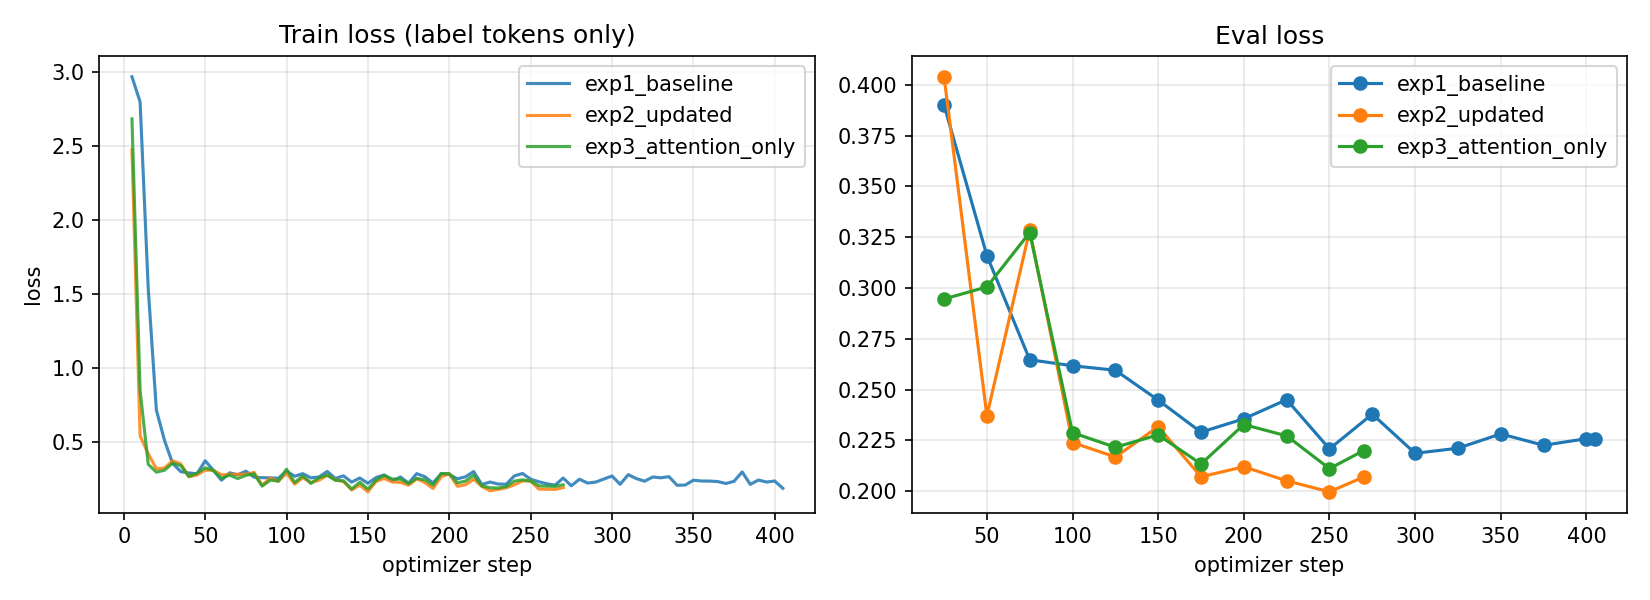

In [7]:
from IPython.display import Image, display
display(Image('data/as02/part_c/learning_curves.png'))

In [8]:
# 6. Part D: 100-prompt evaluations (base vs finetuned), unseen drugs, edge cases
!python3 as02/part_d_generate_eval.py --model models/llms/google/gemma-3-270m-it --data data/as02/splits/test.jsonl --n 100 --tag base_test | tail -30
!python3 as02/part_d_generate_eval.py --model finetuned_exp1_baseline/merged --data data/as02/splits/test.jsonl --n 100 --tag exp1_test | tail -30
!python3 as02/part_d_generate_eval.py --model finetuned_exp2_updated/merged --data data/as02/splits/test.jsonl --n 100 --tag exp2_test | tail -30
!python3 as02/part_d_generate_eval.py --model finetuned_exp2_updated/merged --data data/as02/eval/unseen_drugs_eval.jsonl --n 100 --tag exp2_unseen | tail -30
!python3 as02/part_d_generate_eval.py --model finetuned_exp2_updated/merged --data data/as02/eval/edge_cases.jsonl --n 24 --max-new-tokens 40 --tag exp2_edge | tail -30

Loading weights: 100% 236/236 [00:00<00:00, 4851.54it/s]
      "f1": 0.566
    }
  },
  "confusion(gold->pred)": {
    "POSITIVE": {
      "POSITIVE": 14,
      "NEUTRAL": 0,
      "NEGATIVE": 18,
      "NONE": 0
    },
    "NEUTRAL": {
      "POSITIVE": 5,
      "NEUTRAL": 0,
      "NEGATIVE": 31,
      "NONE": 0
    },
    "NEGATIVE": {
      "POSITIVE": 0,
      "NEUTRAL": 0,
      "NEGATIVE": 32,
      "NONE": 0
    }
  },
  "accuracy_chronic_subgroup": 0.444,
  "accuracy_non_chronic": 0.466,
  "off_by_two_errors (POSITIVE<->NEGATIVE)": 18,
  "example_non_compliant_outputs": []
}

wrote /content/llmbox/data/as02/part_d/chatlog_base_test.json, scores_base_test.json, evalset_base_test.jsonl
Loading weights: 100% 236/236 [00:00<00:00, 5480.56it/s]
      "f1": 0.576
    }
  },
  "confusion(gold->pred)": {
    "POSITIVE": {
      "POSITIVE": 18,
      "NEUTRAL": 13,
      "NEGATIVE": 1,
      "NONE": 0
    },
    "NEUTRAL": {
      "POSITIVE": 6,
      "NEUTRAL": 16,
      "NEGATIVE": 1

In [9]:
# 7. Part D: LLM judge (Pydantic model, local Phi-4-mini as judge) over the finetuned model's answers
!python3 as02/part_d_llm_judge.py --evalset data/as02/part_d/evalset_exp2_test.jsonl | tail -20

Traceback (most recent call last):
  File "/content/llmbox/as02/part_d_llm_judge.py", line 30, in <module>
    from src.pydantic_models.experience_judge import judge_structured, likert_from_labels  # noqa: E402
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/llmbox/src/pydantic_models/experience_judge.py", line 92, in <module>
    str(Path(__file__).resolve().parents[5] / "labs" / "lab01" / "models" / "phi4-mini-instruct"))
        ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^
  File "/usr/lib/python3.13/pathlib/_local.py", line 49, in __getitem__
    raise IndexError(idx)
IndexError: 5


In [10]:
# 8. save results back to GitHub (adapters are small; merged models are ignored) -------
!git config user.email "yarayaocmu2027@gmail.com" && git config user.name "Yara Yao"
!git add data/evaluations data/as02 && git commit -q -m "AS02: Colab A100 results (exp1/exp2/exp3, Part D evals)" && git push -q origin HEAD
# and a zip you can download
!zip -qr as02_results.zip data/evaluations data/as02/part_a data/as02/part_c data/as02/part_d finetuned_exp1_baseline/adapter_model.safetensors finetuned_exp2_updated/adapter_model.safetensors
from google.colab import files; files.download('as02_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Human evaluation (interactive, must be done by each student)
Run in a Colab cell (it prompts in the output area) or locally after pulling the results:
```
!python3 -m startllm mode=evaluate data=jsonl data.path=data/as02/part_d/evalset_exp2_test.jsonl model.local_path=finetuned_exp2_updated/merged
```
When asked for an LLM-judge function paste: `from src.pydantic_models.experience_judge import judge_fn`
